In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
## lets create and range of 50 values in range -1,1
weights = np.linspace(1,-1,50) # Weight with float32 precision
weights

array([ 1.        ,  0.95918367,  0.91836735,  0.87755102,  0.83673469,
        0.79591837,  0.75510204,  0.71428571,  0.67346939,  0.63265306,
        0.59183673,  0.55102041,  0.51020408,  0.46938776,  0.42857143,
        0.3877551 ,  0.34693878,  0.30612245,  0.26530612,  0.2244898 ,
        0.18367347,  0.14285714,  0.10204082,  0.06122449,  0.02040816,
       -0.02040816, -0.06122449, -0.10204082, -0.14285714, -0.18367347,
       -0.2244898 , -0.26530612, -0.30612245, -0.34693878, -0.3877551 ,
       -0.42857143, -0.46938776, -0.51020408, -0.55102041, -0.59183673,
       -0.63265306, -0.67346939, -0.71428571, -0.75510204, -0.79591837,
       -0.83673469, -0.87755102, -0.91836735, -0.95918367, -1.        ])

In [ ]:
## example
# 7Billion parameter model X 4bytes (float32) = 280 GB of ram for inference
# 7B x 1 byte (8bits) = 7 GB model

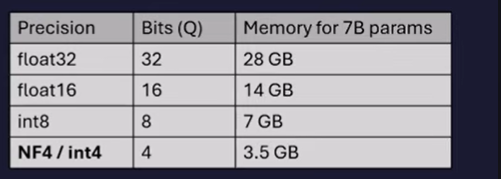

In [4]:
## doing quantization on that weights array
# x - range (-1,1)
# q - int 8 (range -128,127)
# scale = (xmax-xmin)/(qmax-qmin) - this get the scale value
## then
## q = round(x-zero_point)/scale  - this assign that interval value

In [5]:
x_max = 1.0
x_min = -1.0
q_max = 127
q_min = -128

scale = (x_max - x_min) / (q_max - q_min)
scale

0.00784313725490196

In [6]:
zero_point = 0.0 # -> symetric

## quantization : float -> int8
q = np.round((weights - zero_point)/scale).astype(int)

In [11]:
q = np.clip(q,q_min,q_max) # to clip the valid range i.e dont want to go above -128 to 127
q

array([ 127,  122,  117,  112,  107,  101,   96,   91,   86,   81,   75,
         70,   65,   60,   55,   49,   44,   39,   34,   29,   23,   18,
         13,    8,    3,   -3,   -8,  -13,  -18,  -23,  -29,  -34,  -39,
        -44,  -49,  -55,  -60,  -65,  -70,  -75,  -81,  -86,  -91,  -96,
       -101, -107, -112, -117, -122, -128])

In [12]:
# Dequantization : int8 -> float
x_hat = scale * (q - zero_point)
x_hat

array([ 0.99607843,  0.95686275,  0.91764706,  0.87843137,  0.83921569,
        0.79215686,  0.75294118,  0.71372549,  0.6745098 ,  0.63529412,
        0.58823529,  0.54901961,  0.50980392,  0.47058824,  0.43137255,
        0.38431373,  0.34509804,  0.30588235,  0.26666667,  0.22745098,
        0.18039216,  0.14117647,  0.10196078,  0.0627451 ,  0.02352941,
       -0.02352941, -0.0627451 , -0.10196078, -0.14117647, -0.18039216,
       -0.22745098, -0.26666667, -0.30588235, -0.34509804, -0.38431373,
       -0.43137255, -0.47058824, -0.50980392, -0.54901961, -0.58823529,
       -0.63529412, -0.6745098 , -0.71372549, -0.75294118, -0.79215686,
       -0.83921569, -0.87843137, -0.91764706, -0.95686275, -1.00392157])

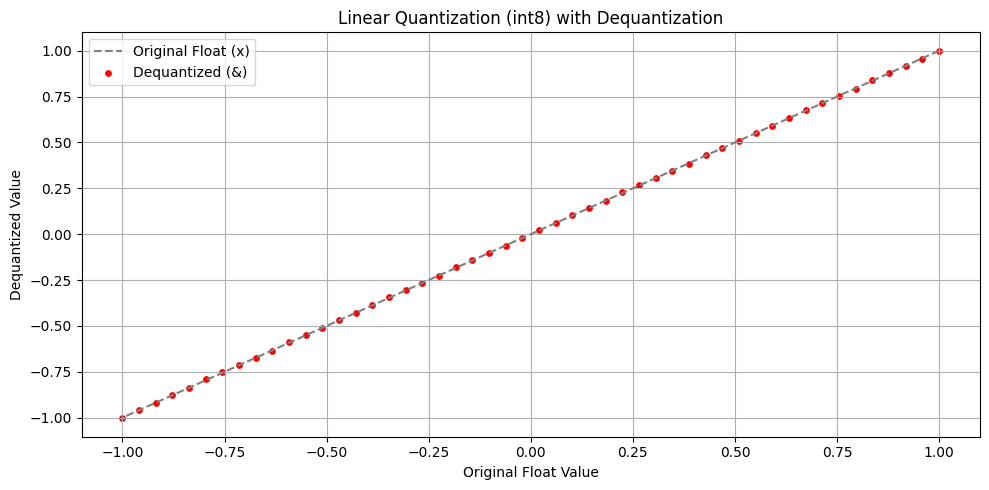

In [14]:
# Plot original vs. dequantized
x = weights
plt.figure(figsize=(10, 5))
plt.plot(x, x, label='Original Float (x)', linestyle='--', color='gray')
plt.scatter(x, x_hat, label='Dequantized (&)', color='red', s=15)
plt.title('Linear Quantization (int8) with Dequantization')
plt.xlabel('Original Float Value')
plt.ylabel('Dequantized Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## NF4 quantization

In [ ]:
## okay here nf4 - 16 bins range (-8,7)
## but the problem is that the when taking the neural network weights and plot it it will form "normal distribution" and with " regular int 4 "
## quantization euqal bins are created that lead to more values around mean and less at end
## Solution - we create bins based on the percentage of data points in histogram
### total area = 100 and 16 bins so (100/16) = 6.25% of data in each bins

## Normal float 4 (NF4)

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define 16 NF4 representative float values
# These are example NF4 values (manually chosen to mimic a Gaussian distribution
# In practice, libraries like bitsandbytes use optimized values
f4_values = np.array([
-1.0, -0.75, -0.5, -0.35, -0.2, -0.1, -0.05, -0.01,
0.01, 0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0])

# Step 2: Simulate original float values
x = np.linspace(-1.0, 1.0, 100)
x[:10]

array([-1.        , -0.97979798, -0.95959596, -0.93939394, -0.91919192,
       -0.8989899 , -0.87878788, -0.85858586, -0.83838384, -0.81818182])

In [19]:
# # Those numbers in f4_values are not just arbitrary points.
#  They are the exact boundaries (or quantile markers) on the x-axis
#  of your histogram that perfectly split the normal distribution into chunks
#  where each chunk contains exactly 6.25% of the total data.

In [ ]:
# quantize x by map with nearest nf4 value

In [27]:
x[:,None].shape , f4_values[None,:].shape

((100, 1), (1, 16))

In [35]:
np.argmin(np.abs(x[:,None] - f4_values[None,:]),axis=1)

array([ 0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,
        3,  3,  4,  4,  4,  4,  4,  4,  4,  5,  5,  5,  6,  6,  6,  7,  8,
        9,  9,  9, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12,
       12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14,
       14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15])

In [36]:
def quantize_nf4(x_vals,nf4_vals):
  idx = np.argmin(np.abs(x_vals[:,None] - nf4_vals[None,:]),axis=1)
  return x_vals[idx]

In [39]:
x_nf4 = quantize_nf4(x,f4_values)
x_nf4

array([-1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -0.97979798, -0.97979798, -0.97979798,
       -0.97979798, -0.97979798, -0.97979798, -0.97979798, -0.97979798,
       -0.97979798, -0.97979798, -0.97979798, -0.97979798, -0.95959596,
       -0.95959596, -0.95959596, -0.95959596, -0.95959596, -0.95959596,
       -0.95959596, -0.95959596, -0.95959596, -0.95959596, -0.93939394,
       -0.93939394, -0.93939394, -0.93939394, -0.93939394, -0.93939394,
       -0.93939394, -0.91919192, -0.91919192, -0.91919192, -0.91919192,
       -0.91919192, -0.91919192, -0.91919192, -0.8989899 , -0.8989899 ,
       -0.8989899 , -0.87878788, -0.87878788, -0.87878788, -0.85858586,
       -0.83838384, -0.81818182, -0.81818182, -0.81818182, -0.7979798 ,
       -0.7979798 , -0.7979798 , -0.77777778, -0.77777778, -0.77777778,
       -0.77777778, -0.77777778, -0.77777778, -0.77777778, -0.75757576,
       -0.75757576, -0.75757576, -0.75757576, -0.75757576, -0.75

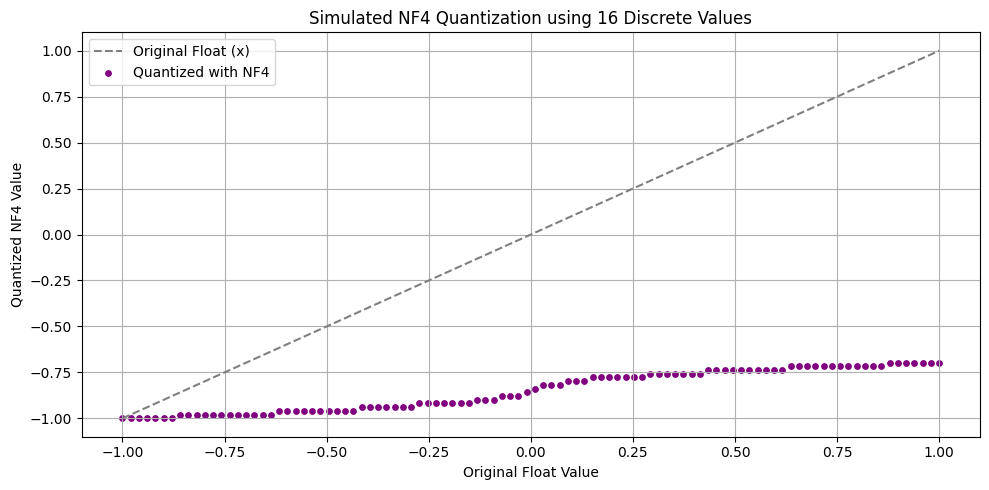

In [44]:
# Step 4: Plot original vs. quantized (NF4)
plt.figure(figsize=(10,5))
plt.plot(x, x, label='Original Float (x)', linestyle='--', color='gray')
plt.scatter(x, x_nf4, label='Quantized with NF4', color='purple', s=15)
plt.title('Simulated NF4 Quantization using 16 Discrete Values')
plt.xlabel('Original Float Value')
plt.ylabel('Quantized NF4 Value')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()